### California Housing Price Regression
------------------------------------------------------------
Goal:
1. Use four regression models to predict California housing prices:
      - K-Nearest Neighbors (KNN)
      - Linear Regression
      - Decision Tree
      - Neural Network
2. Compare their prediction performance on the same test set.
3. Use K-fold cross-validation to choose the neural network's hidden-layer structure and activation function.


In [2]:
# Load Python Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fetch_california_housing downloads/loads the California Housing dataset.
from sklearn.datasets import fetch_california_housing

# train_test_split separates data into training and test sets.
# KFold creates the folds used in K-fold cross-validation.
# GridSearchCV tries different hyperparameter combinations using cross-validation.
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# These are the four regression models used in this demonstration.
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# StandardScaler standardizes features so that they have comparable scales.
# This is especially important for KNN and neural networks.
from sklearn.preprocessing import StandardScaler

# Pipeline allows preprocessing and a model to be treated as one object.
# It also ensures that scaling is fitted using only the training data.
from sklearn.pipeline import Pipeline

# MSE and R^2 are used to evaluate regression predictions.
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# ============================================================
# Part 1. Load and inspect the California Housing dataset
# ============================================================

# Load the dataset.
# as_frame=True returns pandas objects, which are convenient for inspection.
housing = fetch_california_housing(as_frame=True)

# X contains the eight input features.
X = housing.data

# y contains the target: median house value in units of $100,000.
y = housing.target

# Display basic information for students.
print("Feature names:")
print(list(X.columns))
print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nFirst five samples:")
print(X.head())

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Number of samples: 20640
Number of features: 8

First five samples:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [6]:
# ============================================================
# Part 2. Split the data into training and test sets
# ============================================================

# Use 70% of the data for training and 30% for final testing.
# random_state=42 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

### Linear Model

In [8]:
# Define the Regression Model
# Linear regression fits a linear function of the input features.
# Scaling is not required for ordinary least squares, so we use the model directly.
linear_model = LinearRegression()

# Learn the model parameters from the training set.
linear_model.fit(X_train, y_train)

# Predict house values for the training set.
y_train_pred = linear_model.predict(X_train)

# Predict house values for samples that were not used to fit the model.
y_test_pred = linear_model.predict(X_test)

# MSE is the average squared prediction error.
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# RMSE is in the same units as the target and is often easier to interpret.
test_rmse = np.sqrt(test_mse)

# R^2 measures how much of the variation in y is explained by the model.
# A value closer to 1 indicates better predictions.
test_r2 = r2_score(y_test, y_test_pred)

# Save the results for a comparison table.
results = []
results.append({
        "Training MSE": train_mse,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test R^2": test_r2
})

# Convert the results to a DataFrame so that they are easy to read.
results_df = pd.DataFrame(results)
results_df

,Training MSE,Test MSE,Test RMSE,Test R^2
0,0.523358,0.530568,0.728401,0.59577


### More regression models

In [13]:
# ============================================================
# Part 3. Define four regression models
# ============================================================

# KNN compares a new sample with nearby training samples.
# Scaling is important because KNN uses distances between feature vectors.
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

# Linear regression fits a linear function of the input features.
# Scaling is not required for ordinary least squares, so we use the model directly.
linear_model = LinearRegression()

# A decision tree repeatedly splits the feature space into regions.
# Scaling is not required because a tree compares one feature with a threshold at a time.
# max_depth=10 is used here to reduce excessive overfitting in a classroom demonstration.
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# MLPRegressor is scikit-learn's feed-forward neural-network regressor.
# hidden_layer_sizes=(50,) means one hidden layer containing 50 neurons.
# Scaling usually makes neural-network training much more stable.
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(50,),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

# Store all four models in a dictionary so that we can train them in one loop.
models = {
    "KNN (k=5)": knn_model,
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Neural Network": mlp_model
}



In [14]:
# ============================================================
# Part 4. Train and evaluate the four models
# ============================================================

# This list will store the performance of each model.
results = []

# Train each model using exactly the same training data.
for name, model in models.items():

    # Learn the model parameters from the training set.
    model.fit(X_train, y_train)

    # Predict house values for the training set.
    y_train_pred = model.predict(X_train)

    # Predict house values for samples that were not used to fit the model.
    y_test_pred = model.predict(X_test)

    # MSE is the average squared prediction error.
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE is in the same units as the target and is often easier to interpret.
    test_rmse = np.sqrt(test_mse)

    # R^2 measures how much of the variation in y is explained by the model.
    # A value closer to 1 indicates better predictions.
    test_r2 = r2_score(y_test, y_test_pred)

    # Save the results for a comparison table.
    results.append({
        "Model": name,
        "Training MSE": train_mse,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test R^2": test_r2
    })

# Convert the results to a DataFrame so that they are easy to read.
results_df = pd.DataFrame(results)

# Sort from the smallest test MSE to the largest test MSE.
results_df = results_df.sort_values("Test MSE")

print("\n\nPerformance of the four regression models:")
print(results_df.to_string(index=False))



Performance of the four regression models:
            Model  Training MSE  Test MSE  Test RMSE  Test R^2
   Neural Network      0.303298  0.312639   0.559141  0.761806
    Decision Tree      0.218761  0.415452   0.644556  0.683475
        KNN (k=5)      0.280003  0.429494   0.655358  0.672776
Linear Regression      0.523358  0.530568   0.728401  0.595770


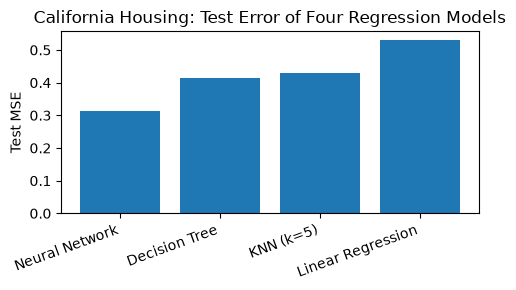

In [17]:
# ============================================================
# Part 5. Visualize the test MSE of the four models
# ============================================================

plt.figure(figsize=(5, 3))

# Each bar represents the test MSE of one model.
plt.bar(results_df["Model"], results_df["Test MSE"])

plt.ylabel("Test MSE")
plt.title("California Housing: Test Error of Four Regression Models")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


============================================================
### Part 6. Use K-fold cross-validation to tune the neural network
============================================================

We now choose two neural-network hyperparameters:
  1. hidden_layer_sizes: the number of hidden layers and neurons per layer
  2. activation: the activation function used by hidden neurons

IMPORTANT:
- The test set is NOT used for this choice.
- Hyperparameters are selected using only the training set.

In [19]:
# Create a neural-network pipeline.
# During cross-validation, StandardScaler is refitted inside every training fold.
# This prevents information from a validation fold from leaking into its training fold.
mlp_for_search = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

# Candidate hyperparameter values.
# In hidden_layer_sizes:
#   (50,)       = 1 hidden layer with 50 neurons
#   (50, 50)    = 2 hidden layers with 50 neurons each
#   (50, 50, 50)= 3 hidden layers with 50 neurons each
#
# The prefix "model__" means that these parameters belong to the
# "model" step of the Pipeline.
parameter_grid = {
    "model__hidden_layer_sizes": [
        (50,),
        (50, 50),
        (50, 50, 50)
    ],
    "model__activation": [
        "relu",
        "tanh",
        "logistic"
    ]
}

# Create a 5-fold cross-validation scheme.
# The training set is divided into five folds.
# Each fold is used once for validation while the other four folds are used for training.
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV trains and validates every combination in parameter_grid.
# scoring="neg_mean_squared_error" is used because GridSearchCV maximizes scores;
# therefore scikit-learn stores MSE with a negative sign.
grid_search = GridSearchCV(
    estimator=mlp_for_search,
    param_grid=parameter_grid,
    cv=kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

print("\n\nRunning 5-fold cross-validation for the neural network...")

# Run the complete hyperparameter search using only the training data.
grid_search.fit(X_train, y_train)

# GridSearchCV automatically refits the best hyperparameter combination
# on the complete training set after cross-validation finishes.
best_mlp = grid_search.best_estimator_

# best_params_ contains the architecture and activation function selected by CV.
print("\nBest neural-network hyperparameters:")
print(grid_search.best_params_)

# best_score_ is negative MSE, so multiply by -1 to obtain the usual positive MSE.
best_cv_mse = -grid_search.best_score_
print(f"Best mean validation MSE from 5-fold CV: {best_cv_mse:.4f}")



Running 5-fold cross-validation for the neural network...

Best neural-network hyperparameters:
{'model__activation': 'tanh', 'model__hidden_layer_sizes': (50, 50, 50)}
Best mean validation MSE from 5-fold CV: 0.2926


In [20]:
# ============================================================
# Part 7. Inspect all K-fold neural-network results
# ============================================================

# cv_results_ contains the result of every tested hyperparameter combination.
cv_results = pd.DataFrame(grid_search.cv_results_)

# Keep only the columns that are most useful for a classroom demonstration.
cv_summary = cv_results[[
    "param_model__hidden_layer_sizes",
    "param_model__activation",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# Convert the negative validation MSE back to ordinary positive MSE.
cv_summary["Mean Validation MSE"] = -cv_summary["mean_test_score"]

# Remove the original negative-score column after the conversion.
cv_summary = cv_summary.drop(columns="mean_test_score")

# Give the remaining columns shorter names.
cv_summary = cv_summary.rename(columns={
    "param_model__hidden_layer_sizes": "Hidden Layers",
    "param_model__activation": "Activation",
    "std_test_score": "Std. of CV Score",
    "rank_test_score": "Rank"
})

# Display the best configurations first.
cv_summary = cv_summary.sort_values("Rank")

print("\nAll neural-network cross-validation results:")
print(cv_summary.to_string(index=False))


All neural-network cross-validation results:
Hidden Layers Activation  Std. of CV Score  Rank  Mean Validation MSE
 (50, 50, 50)       tanh          0.025823     1             0.292647
 (50, 50, 50)       relu          0.008257     2             0.297645
     (50, 50)       relu          0.008070     3             0.303870
     (50, 50)       tanh          0.010103     4             0.312427
        (50,)       tanh          0.011624     5             0.326439
        (50,)       relu          0.037500     6             0.337650
        (50,)   logistic          0.009806     7             0.344425
     (50, 50)   logistic          0.012721     8             0.346242
 (50, 50, 50)   logistic          0.013641     9             0.349102


In [21]:
# ============================================================
# Part 8. Final evaluation of the selected neural network
# ============================================================

# Now, and only now, evaluate the selected neural network on the test set.
# This gives an estimate of how well the selected model generalizes to unseen data.
y_test_pred_best_mlp = best_mlp.predict(X_test)

best_test_mse = mean_squared_error(y_test, y_test_pred_best_mlp)
best_test_rmse = np.sqrt(best_test_mse)
best_test_r2 = r2_score(y_test, y_test_pred_best_mlp)

print("\nFinal performance of the K-fold-selected neural network:")
print(f"Test MSE : {best_test_mse:.4f}")
print(f"Test RMSE: {best_test_rmse:.4f}")
print(f"Test R^2 : {best_test_r2:.4f}")



Final performance of the K-fold-selected neural network:
Test MSE : 0.2664
Test RMSE: 0.5161
Test R^2 : 0.7971


In [ ]:
# ============================================================
# Optional classroom discussion
# ============================================================
# 1. Why does KNN need feature scaling?
# 2. Why does a decision tree not need feature scaling?
# 3. Why can the training error of a decision tree be much smaller than
#    its test error?  (Possible answer: overfitting.)
# 4. Why should the test set not be used to choose hyperparameters?
# 5. In 5-fold cross-validation, how many times is each training sample
#    used for validation?  (Answer: once.)
# 6. Does adding more hidden layers always improve validation performance?
#    The cross-validation results allow students to check this empirically.